# Loading the data

Let's read the data into a Pandas dataframe and look at the first 20 records.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

train_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.train.csv"
test_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.test.csv"

'''
names = [
    'Age','Sex','On Thyroxine','Query on Thyroxine','On Antithyroid Medication',
    'Sick','Pregnant','Thyroid Surgery','I131 Treatment','Query Hypothyroid',
    'Query Hyperthyroid','Lithium','Goiter','Tumor','Hypopituitary','Psych',
    'TSH Measured','TSH','T3 Measured','T3','TT4 Measured','TT4',
    'T4U Measured','T4U','FTI Measured','FTI','TBG Measured','TBG',
    'Referral Source','Class'
]
'''

train_data = pd.read_csv(train_url, header=0, na_values="?")
test_data = pd.read_csv(test_url, header=0)

train_data.columns = train_data.columns.str.strip().str.lower()
test_data.columns = test_data.columns.str.strip().str.lower()

# identify columns by what time of data they hold
numeric_columns = ["age", "tsh", "t3", "tt4", "t4u", "fti"]

# categorical columns are everything else (minus 'class')
categorical_columns = list(set(train_data.columns)-set(numeric_columns)-set(['class']))

In [ ]:
def format_class_labels(df):
    df = df.copy()

    df["class"] = (
        df["class"]
        .astype(str)
        .str.replace(r"\.\|\d+", "", regex=True)
        .str.strip()
        .str.lower()
    )

    df["class"] = df["class"].replace({
        "negative": 0,
        "compensated hypothyroid": 1,
        "primary hypothyroid": 1,
        "secondary hypothyroid": 1
    })

    df = df.dropna(subset=["class"])
    df["class"] = df["class"].astype(int)

    return df

train_data = format_class_labels(train_data)
train_data.head()

/tmp/ipykernel_1027/1745060249.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace({


,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,i131 treatment,query hypothyroid,...,tt4 measured,tt4,t4u measured,t4u,fti measured,fti,tbg measured,tbg,referral source,class
0,41.0,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,NaN,SVHC,0
1,23.0,F,f,f,f,f,f,f,f,f,...,t,102.0,f,NaN,f,NaN,f,NaN,other,0
2,46.0,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,NaN,other,0
3,70.0,F,t,f,f,f,f,f,f,f,...,t,175.0,f,NaN,f,NaN,f,NaN,other,0
4,70.0,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,NaN,SVI,0


In [ ]:
mapping = {
    **dict.fromkeys(["F","f"],0),
    **dict.fromkeys(["M","m"],1),
    "negative":0,
    **dict.fromkeys(["compensated hypothyroid","primary hypothyroid","secondary hypothyroid"], 1)
  }

train_data.replace(mapping, inplace=True)
test_data.replace(mapping, inplace=True)

/tmp/ipykernel_1027/293646903.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data.replace(mapping, inplace=True)
/tmp/ipykernel_1027/293646903.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data.replace(mapping, inplace=True)


In [ ]:
train_data = train_data.drop_duplicates()

In [ ]:
# Columns we will use to make predictions with (features!) feel free to play around with these
X_cols = ['age','sex','on thyroxine','query on thyroxine','on antithyroid medication',
    'sick','pregnant','thyroid surgery','i131 treatment','query hypothyroid',
    'query hyperthyroid','lithium','goiter','tumor','hypopituitary','psych',
    'tsh measured','tsh','t3 measured','t3','tt4 measured','tt4',
    't4u measured','t4u','fti measured','fti','tbg measured','tbg',
    'referral source']

# Column that we want to predict (the labels)
y_col = 'class'

# 80-20 train-test split of datset
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(train_data[X_cols], train_data[y_col], test_size=test_size, random_state=0)

# Further split X and y of training into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

In [ ]:
missing_quantitative = X_train.columns[
    (X_train.isna().sum() > 0) &
    (X_train.dtypes != "object")
]

print(missing_quantitative)

Index(['sex', 'tsh', 't3', 'tt4', 't4u', 'fti', 'tbg'], dtype='object')


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score

# Separate numerical and categorical columns
numeric_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(exclude=np.number).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# SVM model
svm_model = Pipeline([
    ("preprocessing", preprocessor),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=0
    ))
])

svm_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Predictions
y_val_pred = svm_model.predict(X_val)
y_val_prob = svm_model.predict_proba(X_val)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


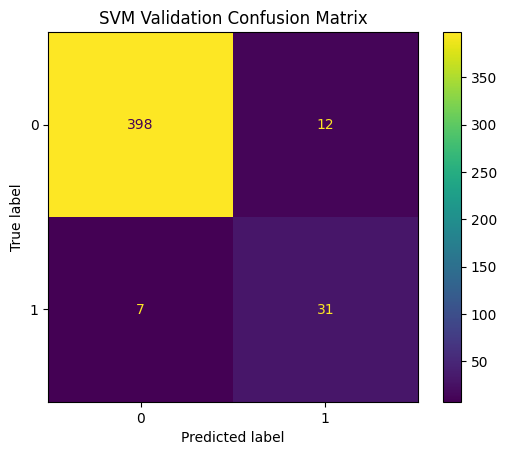

In [ ]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot()
plt.title("SVM Validation Confusion Matrix")
plt.show()

In [ ]:
y_val_probability = svm_model.predict_proba(X_val)[:, 1]

positive_class = svm_model.classes_[1]

y_val_binary = (y_val == positive_class).astype(int)

fpr, tpr, thresholds = roc_curve(
    y_val_binary,
    y_val_probability
)

roc_auc = roc_auc_score(
    y_val_binary,
    y_val_probability
)

print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9625160462130937


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


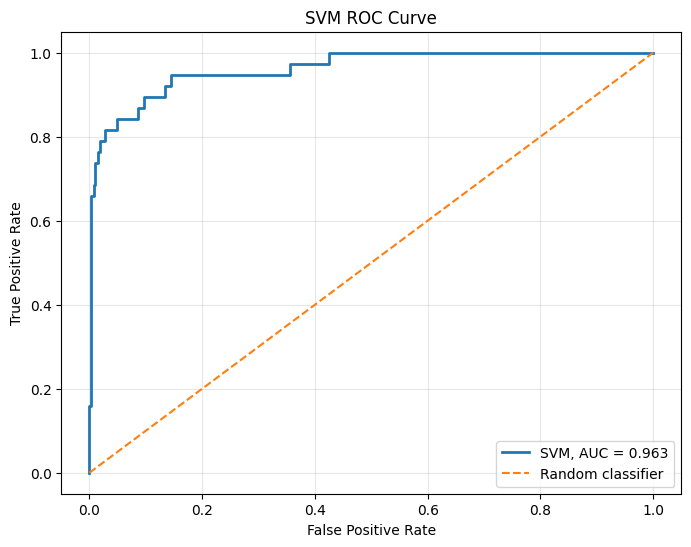

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"SVM, AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Make predictions
y_train_pred = svm_model.predict(X_train)
y_val_pred = svm_model.predict(X_val)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Training Accuracy:", train_accuracy * 100)
print("Validation Accuracy:", val_accuracy * 100)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Training Accuracy: 96.31696428571429
Validation Accuracy: 95.75892857142857


## Data analysis and visualization

In [ ]:
from sklearn.inspection import permutation_importance

# calculate feature importance on VAL data
result = permutation_importance(
    svm_model, # the model
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=0
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base

              Feature  Importance
17                tsh    0.184979
2        on thyroxine    0.011398
16       tsh measured    0.008196
19                 t3    0.007794
25                fti    0.007648
5                sick    0.003553
6            pregnant    0.003438
21                tt4    0.002558
7     thyroid surgery    0.002507
9   query hypothyroid    0.002373


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base

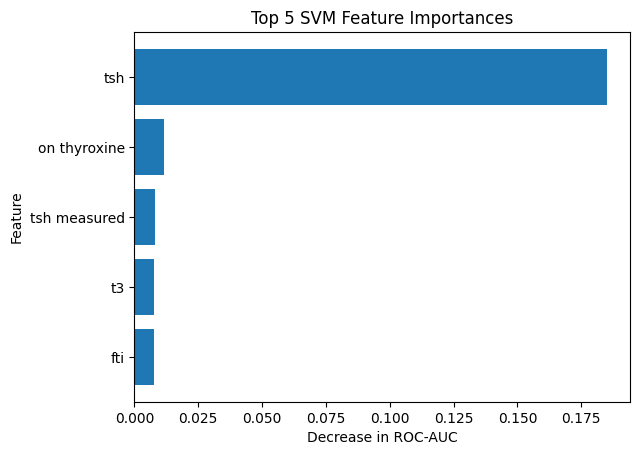

In [ ]:
top_features = importance_df.head(5).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(1)
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Top 5 SVM Feature Importances")
plt.show()

In [ ]:
import shap
import pandas as pd

In [ ]:
# Background data used by SHAP as a reference
background = X_train.sample(50, random_state=0)

# Patients to explain
X_shap = X_val.sample(100, random_state=0)

In [ ]:
def predict_positive(data):
    data = pd.DataFrame(data, columns=X_train.columns)
    return svm_model.predict_proba(data)[:, 1]

In [ ]:
explainer = shap.KernelExplainer(
    predict_positive,
    background
)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
shap_values = explainer.shap_values(
    X_shap,
    nsamples=100
)

  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['tbg']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base

/tmp/ipykernel_7321/1746818829.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


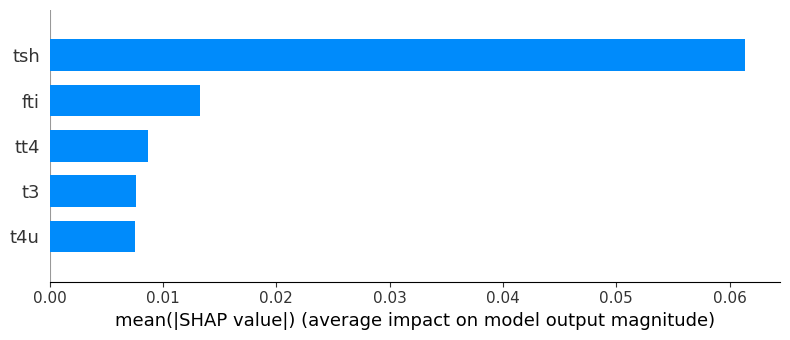

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=5
)

/tmp/ipykernel_7321/1483753833.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


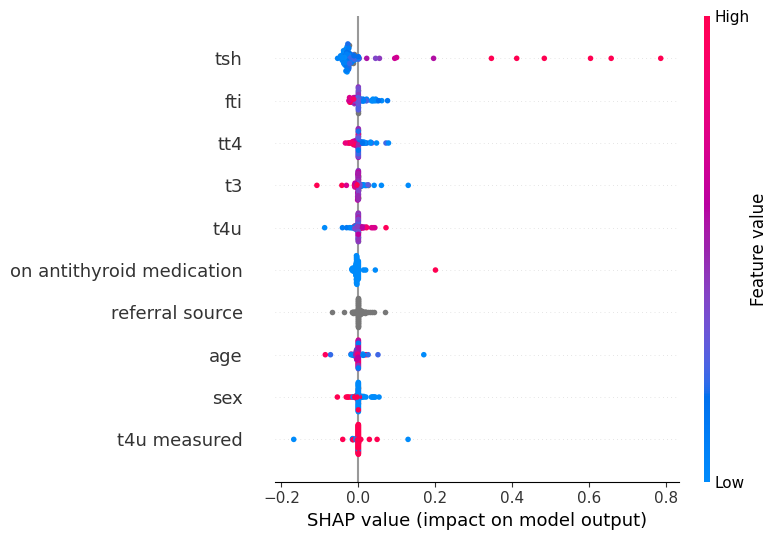

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=10
)

Check the correlation of the dataset

In [ ]:
def zero_rule_algorithm_classification(train,test):
  ## Your code here


Get your baseline performance by calculating the accuracy of your Zero Rule algorithm.

In [ ]:
## Your code here

So maybe accuracy isn't the best performance measure for this dataset. As you've seen already, even when the models predict "negative" for all the records, we could already achieve a ~92% accuracy. However, that also implies we incorrectly predicted 100% of the positive cases, which in the context of this problem, is fatal.

Thankfully, it isn't the only way to evaluate your model. Let's take a look at a confusion matrix.

![alt text](https://i.imgur.com/uipmEwt.png)

Create a confusion matrix using the logistic regression function you built earlier.


Yet another appropriate metric is the Area Under the Receiver Operator Curve. Specifically, the diagnostic performance of a test, or the accuracy of a test to discriminate diseased cases from normal cases is evaluated using Receiver Operating Characteristic (ROC) curve analysis.

When you consider the results of a particular test in two populations, one population with a disease, the other population without the disease, you will rarely observe a perfect separation between the two groups. Hence, the overlapping areas in the diagram below (FN, FP).

In a Receiver Operating Characteristic (ROC) curve the true positive rate (Sensitivity) is plotted in function of the false positive rate (100-Specificity) for different cut-off points. Each point on the ROC curve represents a sensitivity/specificity pair corresponding to a particular decision threshold. A test with perfect discrimination (no overlap in the two distributions) has a ROC curve that passes through the upper left corner (100% sensitivity, 100% specificity). Therefore the closer the ROC curve is to the upper left corner, the higher the overall accuracy of the test.

![alt text](https://www.medcalc.org/manual/_help/images/roc_intro1.png)





# Submitting your Model

Once you believe to have found the best classifier, run your classifier on the test data and make a pickle file containing of your predictions contained a pandas dataframe.

This pandas dataframe will contain three columns for your binary classifier (or 5 columns for the multiclass classifier): the first column should be your model's "best guess" for each patient (either 0 or 1, negative or positive) and the last two columns should be the probability the patient would be classified as either a 0 or 1.

(see below for reference)

In [ ]:
#pickling example
import pickle
predictions=pd.DataFrame({"guesses":[0,1,0,1],"prob_neg":[.75,.15,.63,.20],"prob_pos":[.25,.85,.27,.80]})
prediction_pickle_path = 'prediction_pickle.pkl'

from google.colab import files
# Create an variable to pickle and open it in write mode
prediction_pickle = open(prediction_pickle_path, 'wb')
pickle.dump(predictions, prediction_pickle)
files.download(prediction_pickle_path)
prediction_pickle.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
prediction_unpickle = open(prediction_pickle_path, 'rb')

# load the unpickle object into a variable
predictions = pickle.load(prediction_unpickle)

print(predictions)

   guesses  prob_neg  prob_pos
0        0      0.75      0.25
1        1      0.15      0.85
2        0      0.63      0.27
3        1      0.20      0.80
